# Imports, Constants and Admin

In [33]:
#---Imports and Admin---
from imports import *
from constants import *
from admin_funcs import *
from sim_folder_readers import *
from redshift_snapshot_imports import *
from data_processing import *
from figure_generation import *

today_str = create_date_code()

# Data Handling and Importing

In [34]:
#--- Data Directory Setup---
loc = '/cosma8/data/dp004/lyra/original_sample/' 
suffix = '/output/'

halo = input('Available Simulation Folders:\n'+get_simulation_list()+'\n\n') #Halo selection input

display_halo=halo.replace('_',' ')

create_redshift_file(halo) #Generate snapshot number vs redshift data

target_redshifts=[0,1,2,3,4]
snap_nums=[get_redshift_snap_num(halo,redshift) for redshift in target_redshifts]

output_str='\nSelect target redshift:\n'

counter=0
for redshift in target_redshifts:
    output_str+='Redshift = '+str(redshift)+': Snapshot Number '+str(snap_nums[counter])+'\n'
    counter+=1

int_redshift=int(input(output_str))

snap_num = int(snap_nums[int_redshift]) #Select snapshot given redshift value

subfind_data = ar.gadget_subfind.load_subfind(snap_num, dir=loc + halo + suffix) #Import subfind dataset

redshift=subfind_data.redshift #Retrieve snapshot redshift value from header

sf_m200s=subfind_data.data['fmc2']*10**10*units.M_sun #Import necessary data arrays and apply AstroPy units
sf_r200s=subfind_data.data['frc2']*units.Mpc
sf_positions=subfind_data.data['fpos']*units.Mpc
sf_masses=subfind_data.data['smty']*10**10*units.M_sun
sf_halfmassradii=subfind_data.data['shmt']*units.Mpc

Available Simulation Folders:
halo7
halo12
T0_May_subfind
T4_Aug
T3_Aug
halo8
T2_Aug_adi
T1_Aug
mergertrees

 T1_Aug


T1_Aug Redshift File Already Exists



Select target redshift:
Redshift = 0: Snapshot Number 186
Redshift = 1: Snapshot Number 164
Redshift = 2: Snapshot Number 157
Redshift = 3: Snapshot Number 154
Redshift = 4: Snapshot Number 152
 4


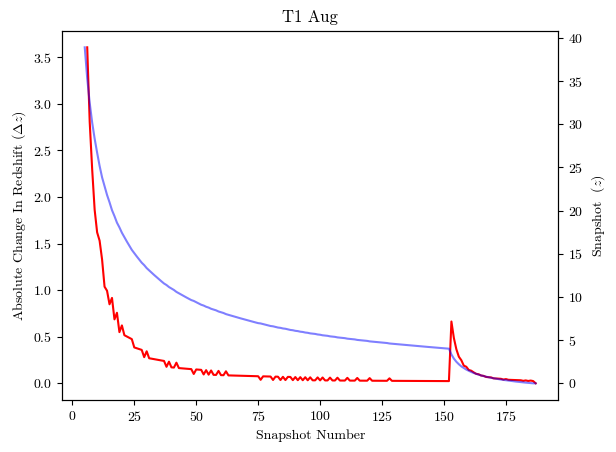

In [54]:
fig_dzsnapshot,ax_dzsnapshot=plt.subplots()

redshift_snapshot=np.float64(np.load('sim_snapshot_redshifts/'+halo+'.npy'))

all_snap_nums=redshift_snapshot[0]
all_redshifts=redshift_snapshot[1]

dz=np.abs(np.diff(all_redshifts))

ax_dzsnapshot.plot(all_snap_nums[1:],dz,c='r')

plt.xlabel('Snapshot Number')
plt.ylabel('Absolute Change In Redshift ($\Delta z$)')

overall=ax_dzsnapshot.twinx()
overall.plot(all_snap_nums,all_redshifts,c='b',alpha=.5)

plt.ylabel('Snapshot  ($z$)')

plt.title(display_halo)

plt.show()

In [35]:
halo_num = int(input('Select FoF Group Number: ')) #Select relevant FoF group

#Import all snapshot data for chosen FoF group (gas, DM, stars)
snapshot_gas = ar.gadget_snap.gadget_snapshot(loc + halo + suffix + 'snapdir_'+str(snap_num)+'/snapshot_'+str(snap_num),loadonlytype=[0],loadonlyhalo = halo_num-1, subfind = subfind_data, hdf5=True, lazy_load=True)
snapshot_dm = ar.gadget_snap.gadget_snapshot(loc + halo + suffix + 'snapdir_'+str(snap_num)+'/snapshot_'+str(snap_num),loadonlytype=[1],loadonlyhalo = halo_num-1, subfind = subfind_data, hdf5=True, lazy_load=True)
snapshot_stars = ar.gadget_snap.gadget_snapshot(loc + halo + suffix + 'snapdir_'+str(snap_num)+'/snapshot_'+str(snap_num),loadonlytype=[4],loadonlyhalo = halo_num-1, subfind = subfind_data, hdf5=True, lazy_load=True)

Select FoF Group Number:  1


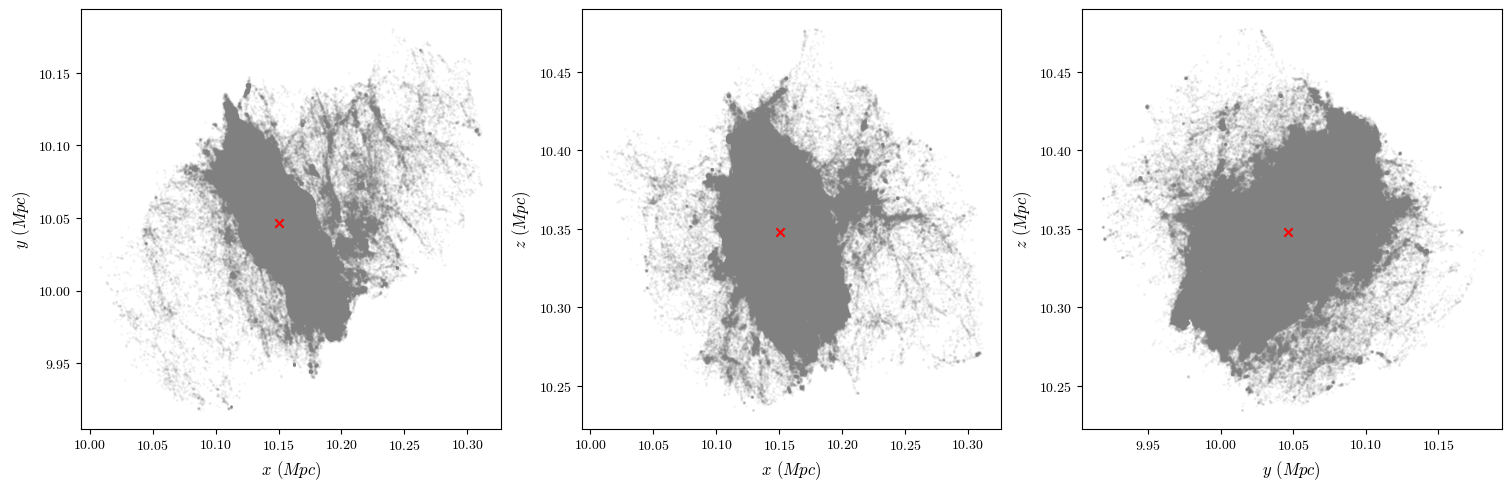

In [37]:
fig_fofscatter,ax_fofscatter=plt.subplots(1,3,figsize=(15,15),constrained_layout=True)

ax_fofscatter[0].scatter(sf_positions[:,0],sf_positions[:,1],s=1,c='gray',alpha=.05)
ax_fofscatter[0].scatter(sf_positions[halo_num-1,0],sf_positions[halo_num-1,1],c='r',marker='x')
ax_fofscatter[0].set_xlabel('$x$ ($Mpc$)')
ax_fofscatter[0].set_ylabel('$y$ ($Mpc$)')

ax_fofscatter[1].scatter(sf_positions[:,0],sf_positions[:,2],s=1,c='gray',alpha=.05)
ax_fofscatter[1].scatter(sf_positions[halo_num-1,0],sf_positions[halo_num-1,2],c='r',marker='x')
ax_fofscatter[1].set_xlabel('$x$ ($Mpc$)')
ax_fofscatter[1].set_ylabel('$z$ ($Mpc$)')

ax_fofscatter[2].scatter(sf_positions[:,1],sf_positions[:,2],s=1,c='gray',alpha=.05)
ax_fofscatter[2].scatter(sf_positions[halo_num-1,1],sf_positions[halo_num-1,2],c='r',marker='x')
ax_fofscatter[2].set_xlabel('$y$ ($Mpc$)')
ax_fofscatter[2].set_ylabel('$z$ ($Mpc$)')

for ax in ax_fofscatter:
        ax.set_box_aspect(1.0)
        ax.xaxis.label.set_size(12)
        ax.yaxis.label.set_size(12)
        ax.tick_params(labelsize=10)

plt.show()

# Initial Data Calculations & Visualisation

## Stellar Half-Light Radius

In [9]:
stellar_halfmass_radii=sf_halfmassradii[halo_num-1,4]

T1_Aug


## Radial Conversions

In [55]:
sn_pos_gas=snapshot_gas.data['pos']*units.Mpc #Import revelant data arrays
sn_mass_gas=snapshot_gas.data['mass']*10**10*units.M_sun

h=snapshot_dm.header['HubbleParam'] #Import h and DM particle mass from snapshot header
dm_particle_mass=snapshot_dm.header['MassTable'][1]/h

sn_pos_dm=snapshot_dm.data['pos']
sn_mass_dm=np.full_like(sn_pos_dm[:,0],dm_particle_mass)*10**10*units.M_sun #Create 1D array of correct length to use DM particle mass imported from header
sn_pos_dm=sn_pos_dm*units.Mpc #Applying astropy.units processing later to allow for np.full_like usage

sn_pos_stars=snapshot_stars.data['pos']*units.Mpc
sn_mass_stars=snapshot_stars.data['mass']*10**10*units.M_sun

halo_pos=sf_positions[halo_num-1]*units.Mpc #Import overall FoF group position from subfind dataset

sn_gas_radii=to_radial(sn_pos_gas,halo_pos) #Convert position vectors to radii relative to the centre of the FoF group
sn_stars_radii=to_radial(sn_pos_stars,halo_pos)
sn_dm_radii=to_radial(sn_pos_dm,halo_pos)

fof_pos_gas=to_relative(sn_pos_gas,halo_pos)
fof_pos_dm=to_relative(sn_pos_dm,halo_pos)
fof_pos_stars=to_relative(sn_pos_stars,halo_pos)

UnitConversionError: Can only apply 'subtract' function to quantities with compatible dimensions

## $M_{\rho_{crit}200}$ vs $R_{\rho_{crit}200}$ Import Verification

In [6]:
halo_r200=sf_r200s[halo_num-1]
halo_m200=sf_m200s[halo_num-1]

def get_type_m200(radii,mass):
    mask=radii<=halo_r200
    r200_masses=mass[mask]
    type_m200=np.sum(r200_masses)
    return type_m200

snapshot_m200=get_type_m200(sn_gas_radii,sn_mass_gas)+get_type_m200(sn_stars_radii,sn_mass_stars)+get_type_m200(sn_dm_radii,sn_mass_dm)

m200_diff=snapshot_m200-halo_m200

print(str(m200_diff/halo_m200*100)+'% Disagreement Between Subfind and Snapshot')

-9.755257365066553% Disagreement Between Subfind and Snapshot


## Position-Mass Histograms

In [7]:
mass_hist_bins=int(input('Number of bins: '))

mass_xy_gas, mass_xz_gas, mass_yz_gas = get_projected_densities(fof_pos_gas,sn_mass_gas,mass_hist_bins,'gas')
mass_xy_dm,mass_xz_dm,mass_yz_dm = get_projected_densities(fof_pos_dm,sn_mass_dm,mass_hist_bins,'dm')
mass_xy_stars,mass_xz_stars,mass_yz_stars = get_projected_densities(fof_pos_stars,sn_mass_stars,mass_hist_bins,'stars')

np.save('xy_gas_projecteddensities/'+halo+'_z'+str(int_redshift)+'_'+'fof'+str(halo_num)+'_binnum'+str(mass_hist_bins)+'_xy_gas_projected_density.npy',mass_xy_gas)

Number of bins:  512


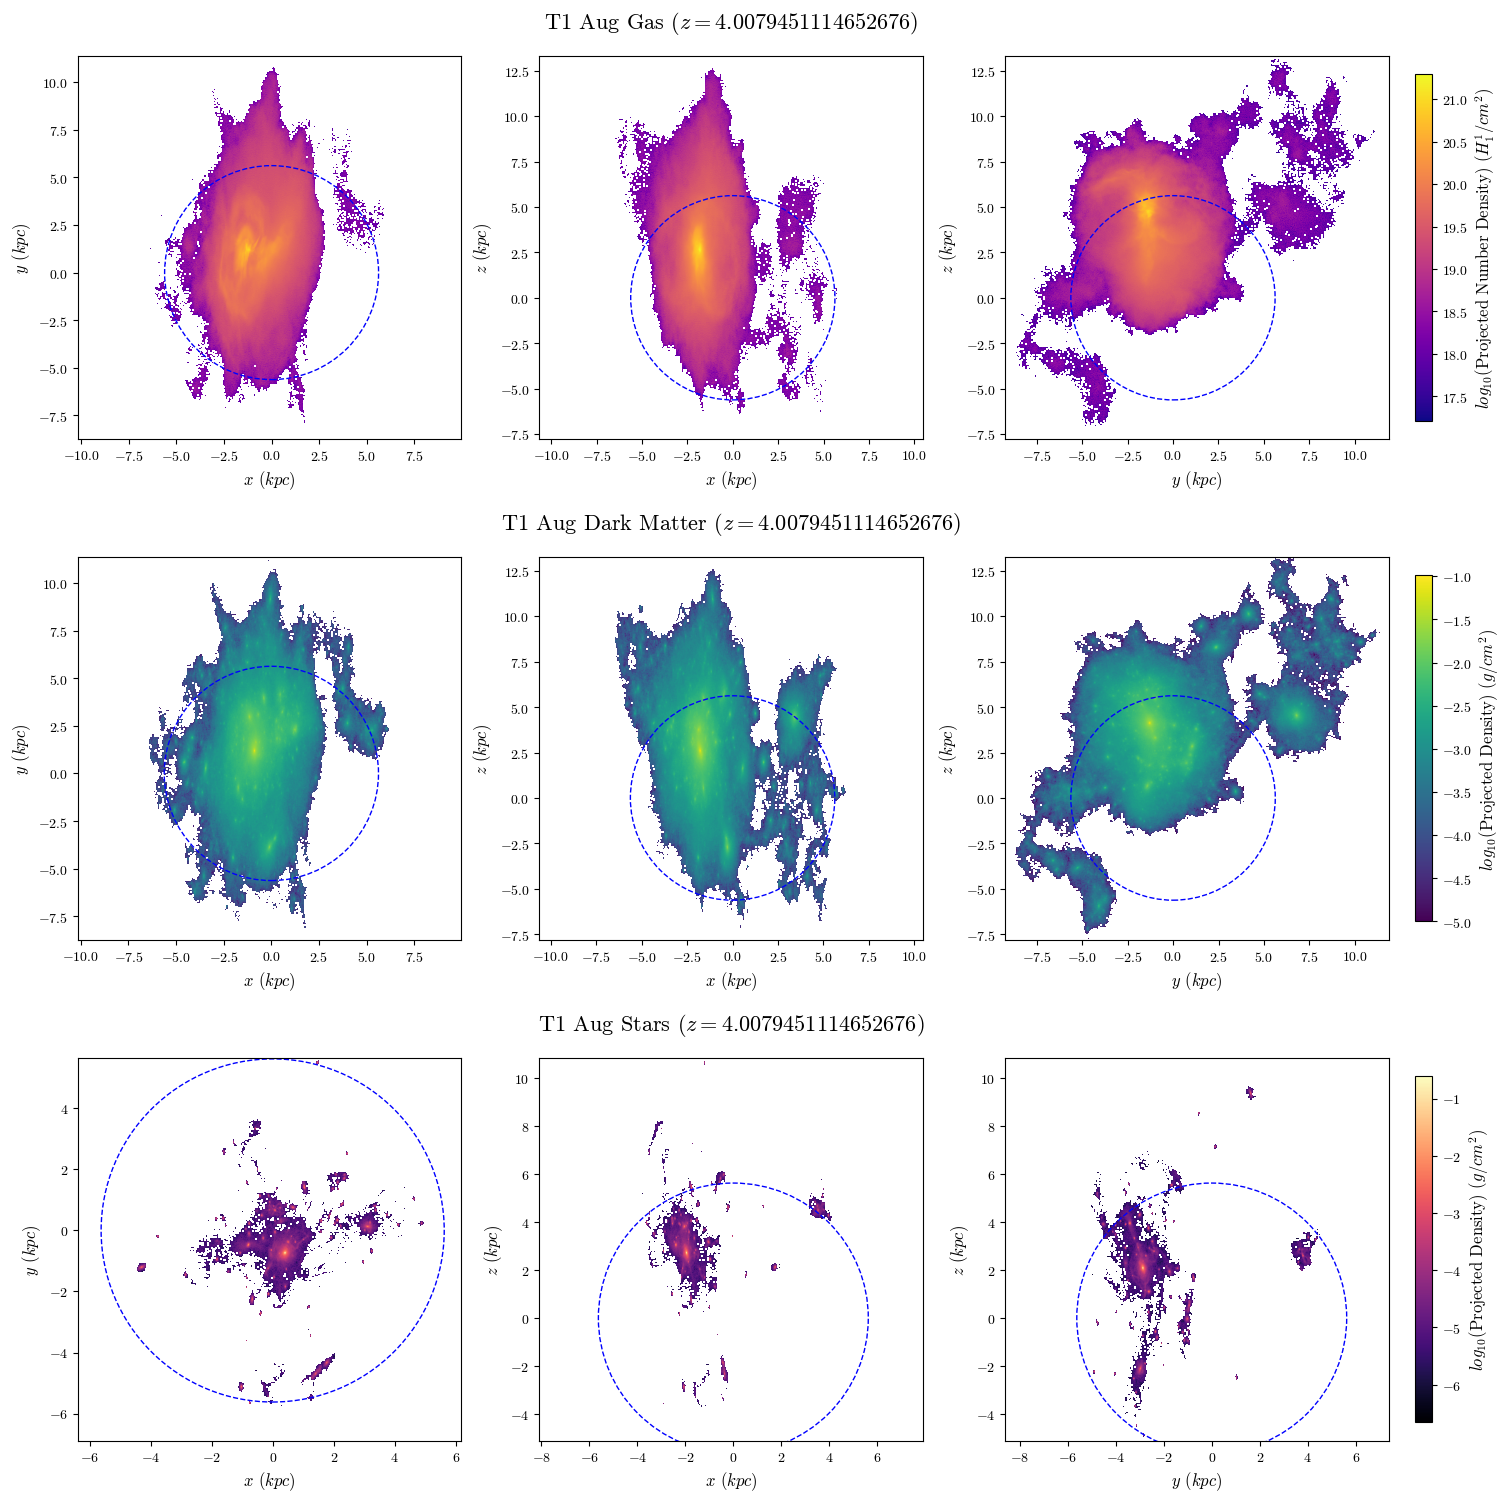

In [11]:
fig_masshist,ax_masshist=plt.subplots(3,3,figsize=(15,15),constrained_layout=True)

plot_projdens_xyz(mass_xy_gas,mass_xz_gas,mass_yz_gas,fof_pos_gas,ax_masshist[0],fig_masshist,'gas',redshift,display_halo)
plot_projdens_xyz(mass_xy_dm,mass_xz_dm,mass_yz_dm,fof_pos_dm,ax_masshist[1],fig_masshist,'dm',redshift,display_halo)
plot_projdens_xyz(mass_xy_stars,mass_xz_stars,mass_yz_stars,fof_pos_stars,ax_masshist[2],fig_masshist,'stars',redshift,display_halo)

for row in ax_masshist:
    for ax in row:
        r200_circle = plt.Circle((0, 0), radius=halo_r200.to_value(units.kpc), color='b', fill=False, linestyle='dashed')
        ax.add_patch(r200_circle)
        
        #halflight_circle=plt.Circle((0,0),radius=stellar_halfmass_radii.to_value(units.kpc),color='r',fill=False,linestyle='dashed')
        #ax.add_patch(halflight_circle)
        
        ax.set_box_aspect(1.0)
        
        ax.xaxis.label.set_size(12)
        ax.yaxis.label.set_size(12)
        ax.tick_params(labelsize=10)

plt.savefig('massperunitareahists/'+today_str+'_'+halo+'_z'+str(int_redshift)+'_fof'+str(halo_num)+'_binnum'+str(mass_hist_bins)+'_xyzmassperunitarea')

plt.show()

# Radial Density Profiles

## Radial Spherical Density Distribution

Number of spherical bins:  30


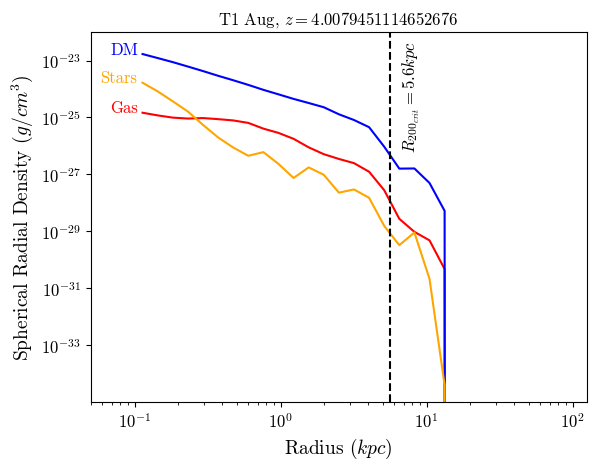

In [12]:
sphere_res = int(input('Number of spherical bins: '))

spherical_bins = np.logspace(-4,-1,sphere_res)*units.Mpc

gas_mass_per_bin=stats.binned_statistic(sn_gas_radii,sn_mass_gas,bins=spherical_bins,statistic='sum')
dm_mass_per_bin=stats.binned_statistic(sn_dm_radii,sn_mass_dm,bins=spherical_bins,statistic='sum')
stars_mass_per_bin=stats.binned_statistic(sn_stars_radii,sn_mass_stars,bins=spherical_bins,statistic='sum')

sphere_volumes=[4/3*np.pi*radii.value**3 for radii in spherical_bins]

shell_volumes=np.diff(sphere_volumes)

gas_densities=gas_mass_per_bin.statistic/shell_volumes*units.M_sun/units.Mpc**3
dm_densities=dm_mass_per_bin.statistic/shell_volumes*units.M_sun/units.Mpc**3
stars_densities=stars_mass_per_bin.statistic/shell_volumes*units.M_sun/units.Mpc**3

fig_radialdensity, ax_radialdensity = plt.subplots()

bin_centres=(spherical_bins[:-1] + spherical_bins[1:])/2

ax_radialdensity.plot(bin_centres.to_value(units.kpc),gas_densities.to_value(units.g/units.cm**3),c='r')
ax_radialdensity.plot(bin_centres.to_value(units.kpc),dm_densities.to_value(units.g/units.cm**3),c='b')
ax_radialdensity.plot(bin_centres.to_value(units.kpc),stars_densities.to_value(units.g/units.cm**3),c='orange')
ax_radialdensity.axvline(halo_r200.to_value(units.kpc),c='k',ls='dashed')

ax_radialdensity.xaxis.label.set_size(14)
ax_radialdensity.yaxis.label.set_size(14)
ax_radialdensity.tick_params(labelsize=12)

plt.text(bin_centres.to_value(units.kpc)[0]-.045, gas_densities.to_value(units.g/units.cm**3)[0], 'Gas', fontsize=12,c='r')
plt.text(bin_centres.to_value(units.kpc)[0]-.045, dm_densities.to_value(units.g/units.cm**3)[0], 'DM', fontsize=12,c='b')
plt.text(bin_centres.to_value(units.kpc)[0]-.055, stars_densities.to_value(units.g/units.cm**3)[0], 'Stars', fontsize=12,c='orange')
plt.text(halo_r200.to_value(units.kpc)+1, 10**-26, '$R_{200_{crit}}=$'+str(round(halo_r200.to_value(units.kpc),1))+'$ kpc$', fontsize=12,c='k',rotation='vertical')

plt.yscale('log')
plt.xscale('log')
plt.xlabel('Radius ($kpc$)')
plt.ylabel('Spherical Radial Density ($g/cm^3$)')
plt.xlim(left=0.05)
plt.ylim(top=10**-22)
plt.title(display_halo+', $z=$'+str(redshift))

plt.savefig('radialdensityprofiles/'+today_str+'_'+halo+'_z'+str(int_redshift)+'_fof'+str(halo_num)+'_radialdensityprofile')

plt.show()

# Gas Metallicity Profiles

## Data Imports

In [13]:
sn_gz_gas=snapshot_gas.data['gz']/z_sol
sn_gmet_gas=snapshot_gas.data['gmet']

## Mass-Weighted Metallicity Histogram

/tmp/ipykernel_2282604/4007899679.py:19: RuntimeWarning: invalid value encountered in divide
  mass_weighted_mean_gz_xy=np.divide(weighted_metallicity_xy,gz_xy_binned_mass)
/tmp/ipykernel_2282604/4007899679.py:20: RuntimeWarning: invalid value encountered in divide
  mass_weighted_mean_gz_xz=np.divide(weighted_metallicity_xz,gz_xz_binned_mass)
/tmp/ipykernel_2282604/4007899679.py:21: RuntimeWarning: invalid value encountered in divide
  mass_weighted_mean_gz_yz=np.divide(weighted_metallicity_yz,gz_yz_binned_mass)


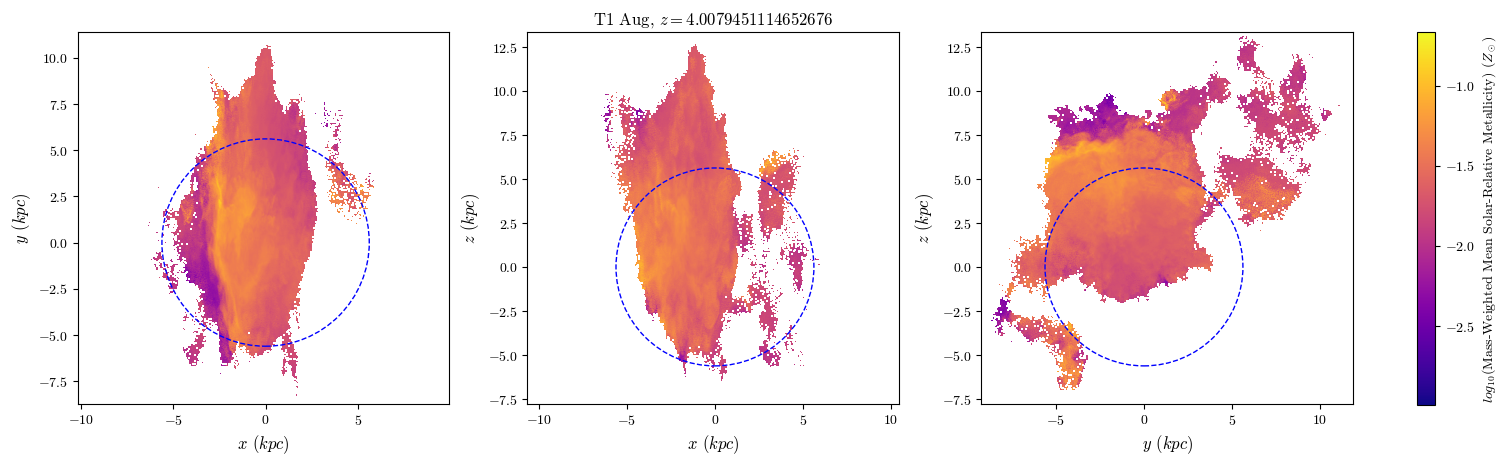

In [14]:
total_mass=np.sum(sn_mass_gas)

colourmap='plasma'

gz_xy_binned=stats.binned_statistic_2d(fof_pos_gas[:,0],fof_pos_gas[:,1],sn_mass_gas,bins=[mass_hist_bins,mass_hist_bins],statistic='sum')
gz_xy_binned_mass=gz_xy_binned.statistic

gas_x_bin_edges=gz_xy_binned.x_edge
gas_y_bin_edges=gz_xy_binned.y_edge
gas_bin_num=gz_xy_binned.binnumber

gz_xz_binned_mass=stats.binned_statistic_2d(fof_pos_gas[:,0],fof_pos_gas[:,2],sn_mass_gas,bins=[mass_hist_bins,mass_hist_bins],statistic='sum').statistic
gz_yz_binned_mass=stats.binned_statistic_2d(fof_pos_gas[:,1],fof_pos_gas[:,2],sn_mass_gas,bins=[mass_hist_bins,mass_hist_bins],statistic='sum').statistic

weighted_metallicity_xy=stats.binned_statistic_2d(fof_pos_gas[:,0],fof_pos_gas[:,1],sn_gz_gas*sn_mass_gas,bins=[mass_hist_bins,mass_hist_bins],statistic='sum').statistic
weighted_metallicity_xz=stats.binned_statistic_2d(fof_pos_gas[:,0],fof_pos_gas[:,2],sn_gz_gas*sn_mass_gas,bins=[mass_hist_bins,mass_hist_bins],statistic='sum').statistic
weighted_metallicity_yz=stats.binned_statistic_2d(fof_pos_gas[:,1],fof_pos_gas[:,2],sn_gz_gas*sn_mass_gas,bins=[mass_hist_bins,mass_hist_bins],statistic='sum').statistic

mass_weighted_mean_gz_xy=np.divide(weighted_metallicity_xy,gz_xy_binned_mass)
mass_weighted_mean_gz_xz=np.divide(weighted_metallicity_xz,gz_xz_binned_mass)
mass_weighted_mean_gz_yz=np.divide(weighted_metallicity_yz,gz_yz_binned_mass)

vmin_gz=np.log10(np.nanmin([mass_weighted_mean_gz_xy,mass_weighted_mean_gz_xz,mass_weighted_mean_gz_yz]))
vmax_gz=np.log10(np.nanmax([mass_weighted_mean_gz_xy,mass_weighted_mean_gz_xz,mass_weighted_mean_gz_yz]))


fig_weightedmetallicity, ax_weightedmetallicity=plt.subplots(1,3,figsize=(15,15),constrained_layout=True)

ax_weightedmetallicity[0].imshow(np.log10(mass_weighted_mean_gz_xy),extent=[np.min(fof_pos_gas[:,0]).value,np.max(fof_pos_gas[:,0]).value, np.min(fof_pos_gas[:,1]).value,np.max(fof_pos_gas[:,1]).value],vmin=vmin_gz,vmax=vmax_gz,cmap=colourmap,aspect='equal')
ax_weightedmetallicity[0].set_xlabel('$x$ ($kpc$)')
ax_weightedmetallicity[0].set_ylabel('$y$ ($kpc$)')

ax_weightedmetallicity[1].imshow(np.log10(mass_weighted_mean_gz_xz),extent=[np.min(fof_pos_gas[:,0]).value,np.max(fof_pos_gas[:,0]).value, np.min(fof_pos_gas[:,2]).value,np.max(fof_pos_gas[:,2]).value],vmin=vmin_gz,vmax=vmax_gz,cmap=colourmap,aspect='equal')
ax_weightedmetallicity[1].set_xlabel('$x$ ($kpc$)')
ax_weightedmetallicity[1].set_ylabel('$z$ ($kpc$)')
ax_weightedmetallicity[1].set_title(display_halo+', $z=$'+str(redshift))

metallicity_colourbar=fig_weightedmetallicity.colorbar(ax_weightedmetallicity[2].imshow(np.log10(mass_weighted_mean_gz_yz),extent=[np.min(fof_pos_gas[:,1]).value,np.max(fof_pos_gas[:,1]).value, np.min(fof_pos_gas[:,2]).value,np.max(fof_pos_gas[:,2]).value],vmin=vmin_gz,vmax=vmax_gz,cmap=colourmap,aspect='equal'),ax=ax_weightedmetallicity[:],shrink=.25)
metallicity_colourbar.set_label('$log_{10}($Mass-Weighted Mean Solar-Relative Metallicity$)$ ($Z_\odot$)',fontsize=10)
ax_weightedmetallicity[2].set_xlabel('$y$ ($kpc$)')
ax_weightedmetallicity[2].set_ylabel('$z$ ($kpc$)')

for ax in ax_weightedmetallicity:
        r200_circle = plt.Circle((0, 0), radius=halo_r200.to_value(units.kpc), color='b', fill=False, linestyle='dashed')
        ax.add_patch(r200_circle)
        ax.set_aspect('equal', adjustable='box')
        ax.set_box_aspect(1.0)
        ax.xaxis.label.set_size(12)
        ax.yaxis.label.set_size(12)
        ax.tick_params(labelsize=10)

np.save('xy_metallicites/'+halo+'_z'+str(int_redshift)+'_'+'fof'+str(halo_num)+'_binnum'+str(mass_hist_bins)+'_xy_metallicity.npy',mass_weighted_mean_gz_xy)

plt.savefig('massweightedmetallicity/'+today_str+'_'+halo+'_z'+str(int_redshift)+'_'+'xyzmassweightedmetallicity')

plt.show()

## Mean Metallicity Radial Profile

Number of spherical bins:  30


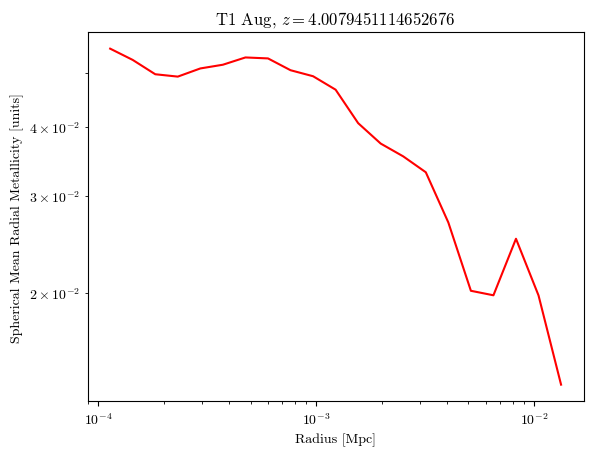

In [15]:
gz_sphere_res = int(input('Number of spherical bins: '))

gz_spherical_bins = np.logspace(-4,-1,gz_sphere_res)

gas_mean_gz_per_bin=stats.binned_statistic(sn_gas_radii,sn_gz_gas,bins=gz_spherical_bins,statistic='mean').statistic
    
fig_gzradial, ax_gzradial = plt.subplots()

gz_bin_centres=(gz_spherical_bins[:-1] + gz_spherical_bins[1:])/2

ax_gzradial.plot(gz_bin_centres,gas_mean_gz_per_bin,c='r')
#ax_gzradial.axvline(halo_r200,c='k',ls='dashed')

plt.yscale('log')
plt.xscale('log')
plt.xlabel('Radius [Mpc]')
plt.ylabel('Spherical Mean Radial Metallicity [units]')
plt.title(display_halo+', $z=$'+str(redshift))


plt.savefig('meanmetallicityradialprofiles/'+today_str+'_'+halo+'_z'+str(int_redshift)+'_fof'+str(halo_num)+'_radialmetallicityprofile')

plt.show()

# Projected Density vs Metallicity Scatter Plot

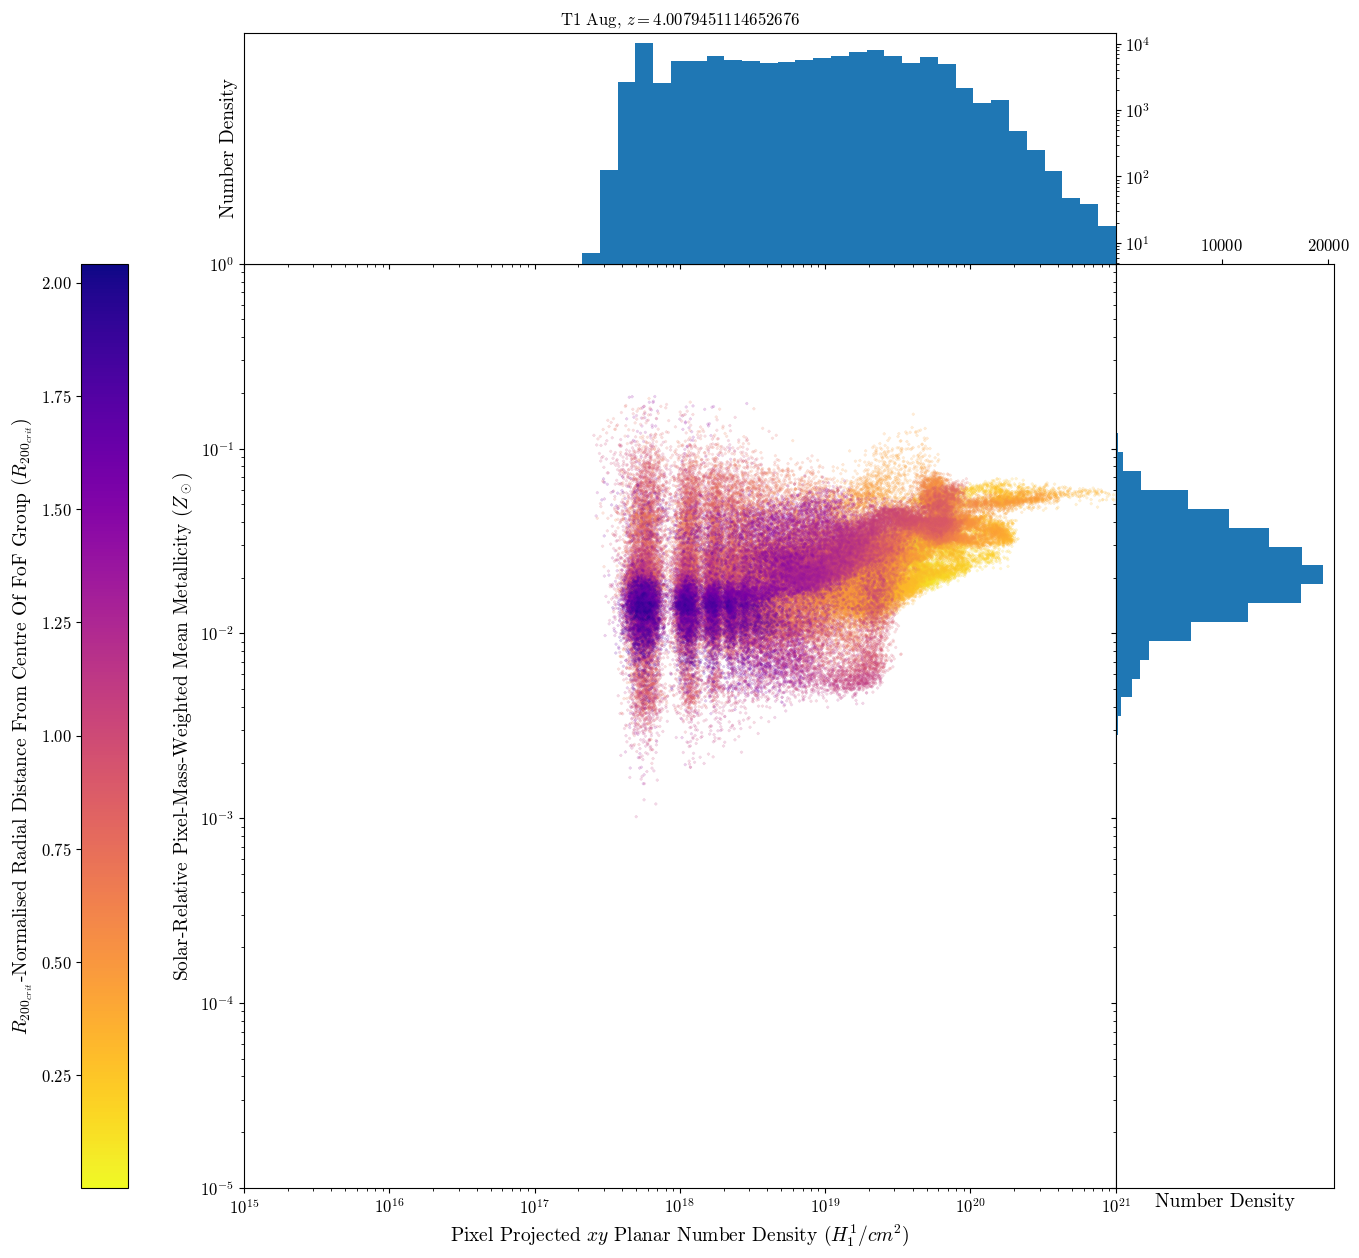

In [18]:
fig_scatter, ax_scatter=plt.subplots(figsize=(15,12))

hists_bin_num=50

x_gas_bincentres=(gas_x_bin_edges[:-1]+gas_x_bin_edges[1:])/2
y_gas_bincentres=(gas_y_bin_edges[:-1]+gas_y_bin_edges[1:])/2

x_bingrid,y_bingrid=np.meshgrid(x_gas_bincentres,y_gas_bincentres)

xy_gas_radii=np.sqrt(x_bingrid**2+y_bingrid**2)

np.save('gas_radii/'+halo+'_z'+str(int_redshift)+'_'+'fof'+str(halo_num)+'_binnum'+str(mass_hist_bins)+'_xy_gas_radii.npy',xy_gas_radii)

scatter=ax_scatter.scatter(mass_xy_gas.flatten(),mass_weighted_mean_gz_xy.flatten(),marker='x',c=xy_gas_radii/halo_r200.to_value(units.kpc),cmap='plasma_r',s=2,alpha=.2)

plt.xlabel('Pixel Projected $xy$ Planar Number Density ($H_1^1/cm^2$)',fontsize=14)
plt.ylabel('Solar-Relative Pixel-Mass-Weighted Mean Metallicity ($Z_\odot$)',fontsize=14)
ax_scatter.tick_params(labelsize=12)

scatter_colourbar=fig_scatter.colorbar(scatter, ax=ax_scatter,location='left')
scatter_colourbar.solids.set_alpha(1)
scatter_colourbar.ax.tick_params(labelsize=12)
scatter_colourbar.set_label('$R_{200_{crit}}$-Normalised Radial Distance From Centre Of FoF Group ($R_{200_{crit}}$)',fontsize=14)

plt.xlim([np.float64(10**15),np.float64(10**21)])
plt.ylim([10**-5,1])
plt.yscale('log')
plt.xscale('log')

left,bottom,width,height=ax_scatter.get_position().bounds

ax_projdenshist=fig_scatter.add_axes([left,bottom+height,width,height/4],sharex=ax_scatter)
ax_projdenshist.hist(mass_xy_gas.flatten(),bins=np.logspace(15,21,hists_bin_num))
plt.yscale('log')
plt.title(display_halo+', $z=$'+str(redshift))

ax_projdenshist.tick_params(labelbottom=False,labelleft=False,labelright=True,labelsize=12)
ax_projdenshist.yaxis.tick_right()
ax_projdenshist.set_ylabel('Number Density',fontsize=14)

ax_gzhist=fig_scatter.add_axes([left+width,bottom,width/4,height],sharey=ax_scatter)
ax_gzhist.hist(mass_weighted_mean_gz_xy.flatten(),bins=np.logspace(-5,0,hists_bin_num),orientation='horizontal')
plt.yscale('log')

ax_gzhist.tick_params(labelleft=False,labelbottom=False,labeltop=True,labelsize=12)
ax_gzhist.xaxis.tick_top()
ax_gzhist.set_xlabel('Number Density',fontsize=14)
gzhist_labels=ax_gzhist.get_xticklabels()
gzhist_labels[0].set_visible(False)

plt.savefig('projdens_gz_scatters/'+today_str+'_'+halo+'_z'+str(int_redshift)+'_fof'+str(halo_num)+'_binnum'+str(mass_hist_bins)+'_projdens_gz_plot',bbox_inches='tight')

plt.show()